# Esercizio 03 — Plain vanilla option pricing

In questo esercizio stimiamo con metodo Monte Carlo il prezzo a $t=0$ di una call europea e di una put europea nel modello di Black-Scholes. I risultati numerici sono confrontati con i valori analitici del modello.

I parametri del problema sono:

| Parametro | Valore |
|---|---:|
| Prezzo iniziale | $S(0)=100$ |
| Strike price | $K=100$ |
| Scadenza | $T=1$ |
| Tasso risk-free | $r=0.1$ |
| Volatilità | $\sigma=0.25$ |
| Intervalli temporali nel metodo discretizzato | $100$ |

## Modello teorico

Nel modello di Black-Scholes il prezzo dell'asset segue un moto browniano geometrico:

$$
dS(t) = rS(t)dt + \sigma S(t)dW(t).
$$

La soluzione esatta tra $0$ e $T$ è:

$$
S(T)=S(0)\exp\left[\left(r-\frac{1}{2}\sigma^2\right)T+\sigma W(T)\right].
$$

Poiché $W(T)$ è una variabile gaussiana con media nulla e varianza $T$, possiamo scrivere:

$$
W(T)=Z\sqrt{T},
\qquad Z \sim \mathcal{N}(0,1).
$$

Il prezzo di una call e di una put europea si ottiene come valore atteso scontato dei rispettivi payoff:

$$
C = e^{-rT}\left\langle \max(0,S(T)-K) \right\rangle,
$$

$$
P = e^{-rT}\left\langle \max(0,K-S(T)) \right\rangle.
$$

## Valori analitici di Black-Scholes

Per confrontare i risultati Monte Carlo usiamo le formule analitiche:

$$
C = S_0N(d_1)-Ke^{-rT}N(d_2),
$$

$$
P = S_0\left[N(d_1)-1\right]-Ke^{-rT}\left[N(d_2)-1\right],
$$

dove

$$
d_1=\frac{\ln(S_0/K)+\left(r+\frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}},
\qquad
d_2=d_1-\sigma\sqrt{T}.
$$

La funzione $N(x)$ è la cumulativa della normale standard:

$$
N(x)=\frac{1}{2}\left[1+\operatorname{erf}\left(\frac{x}{\sqrt{2}}\right)\right].
$$

## Metodo Monte Carlo

La consegna richiede due procedure di campionamento.

Nel primo caso campioniamo direttamente il prezzo finale $S(T)$ usando la soluzione esatta del moto browniano geometrico:

$$
S(T)=S(0)\exp\left[\left(r-\frac{1}{2}\sigma^2\right)T+\sigma Z\sqrt{T}\right].
$$

Nel secondo caso costruiamo il cammino discretizzato dividendo l'intervallo $[0,T]$ in $100$ intervalli. A ogni passo usiamo:

$$
S(t_{i+1})=
S(t_i)\exp\left[\left(r-\frac{1}{2}\sigma^2\right)\Delta t+\sigma Z_i\sqrt{\Delta t}\right],
$$

con

$$
\Delta t=\frac{T}{100}.
$$

È importante osservare che questa ricorrenza non è una discretizzazione approssimativa della SDE. Per il moto browniano geometrico con parametri costanti si conosce infatti la soluzione esatta tra due tempi consecutivi. La formula precedente campiona quindi esattamente la distribuzione di $S(t_{i+1})$ condizionata a $S(t_i)$.

Per una plain vanilla europea il payoff dipende solo dal prezzo finale $S(T)$. Quindi i due metodi devono produrre risultati compatibili entro l'incertezza statistica, stimata come nei precedenti esercizi tramite data blocking.

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

S0 = 100.0
K = 100.0
T = 1.0
r = 0.1
sigma = 0.25

def normal_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def black_scholes_call(S0, K, T, r, sigma):
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * normal_cdf(d1) - K * math.exp(-r * T) * normal_cdf(d2)

def black_scholes_put(S0, K, T, r, sigma):
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * (normal_cdf(d1) - 1.0) - K * math.exp(-r * T) * (normal_cdf(d2) - 1.0)

call_exact = black_scholes_call(S0, K, T, r, sigma)
put_exact = black_scholes_put(S0, K, T, r, sigma)

print(f"Call Black-Scholes = {call_exact:.10f}")
print(f"Put Black-Scholes  = {put_exact:.10f}")
print(f"Put-call parity    = {S0 - K * math.exp(-r * T):.10f}")

Call Black-Scholes = 14.9757907783
Put Black-Scholes  = 5.4595325819
Put-call parity    = 9.5162581964


I valori analitici ottenuti sono circa:

$$
C_{\mathrm{BS}} \simeq 14.9758,
\qquad
P_{\mathrm{BS}} \simeq 5.4595.
$$

Questi valori saranno usati come riferimento nei grafici.

In [2]:
result_files = {
    "call_direct": "call_direct_results.txt",
    "put_direct": "put_direct_results.txt",
    "call_discrete": "call_discrete_results.txt",
    "put_discrete": "put_discrete_results.txt",
}

results_dir = Path("results")

data = {
    name: np.loadtxt(results_dir / file_name)
    for name, file_name in result_files.items()
}

In [3]:
def final_estimate(data_array):
    return data_array[-1, 1], data_array[-1, 2]

summary = pd.DataFrame([
    {
        "Metodo": "Diretto",
        "Opzione": "Call",
        "Stima finale": final_estimate(data["call_direct"])[0],
        "Incertezza": final_estimate(data["call_direct"])[1],
        "Valore Black-Scholes": call_exact,
    },
    {
        "Metodo": "Diretto",
        "Opzione": "Put",
        "Stima finale": final_estimate(data["put_direct"])[0],
        "Incertezza": final_estimate(data["put_direct"])[1],
        "Valore Black-Scholes": put_exact,
    },
    {
        "Metodo": "Discretizzato",
        "Opzione": "Call",
        "Stima finale": final_estimate(data["call_discrete"])[0],
        "Incertezza": final_estimate(data["call_discrete"])[1],
        "Valore Black-Scholes": call_exact,
    },
    {
        "Metodo": "Discretizzato",
        "Opzione": "Put",
        "Stima finale": final_estimate(data["put_discrete"])[0],
        "Incertezza": final_estimate(data["put_discrete"])[1],
        "Valore Black-Scholes": put_exact,
    },
])

summary["Scarto"] = summary["Stima finale"] - summary["Valore Black-Scholes"]
summary["|Scarto| / incertezza"] = np.where(
    summary["Incertezza"] > 0,
    np.abs(summary["Scarto"]) / summary["Incertezza"],
    np.nan,
)

summary

,Metodo,Opzione,Stima finale,Incertezza,Valore Black-Scholes,Scarto,|Scarto| / incertezza
0,Diretto,Call,14.99140,0.061567,14.975791,0.015609,0.253534
1,Diretto,Put,5.44982,0.029230,5.459533,-0.009713,0.332286
2,Discretizzato,Call,14.91380,0.069145,14.975791,-0.061991,0.896530
3,Discretizzato,Put,5.44955,0.029770,5.459533,-0.009983,0.335328


## Campionamento diretto di $S(T)$

Nel campionamento diretto estraiamo direttamente il prezzo finale dell'asset dalla distribuzione lognormale prevista dal moto browniano geometrico. Questo è il metodo più efficiente per una plain vanilla europea, perché non serve conoscere il cammino intermedio dell'asset. Le barre d'errore nei grafici sono ottenute con data blocking.

In [4]:
def plot_progressive_estimate(data_array, exact_value, title, ylabel):
    n_blocks = data_array[:, 0]
    estimate = data_array[:, 1]
    uncertainty = data_array[:, 2]

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        n_blocks,
        estimate,
        yerr=uncertainty,
        fmt="o",
        markersize=3,
        capsize=3,
        label="Monte Carlo"
    )
    plt.axhline(
        exact_value,
        linestyle="--",
        label=f"Black-Scholes = {exact_value:.5f}"
    )
    plt.xlabel("Numero di blocchi")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

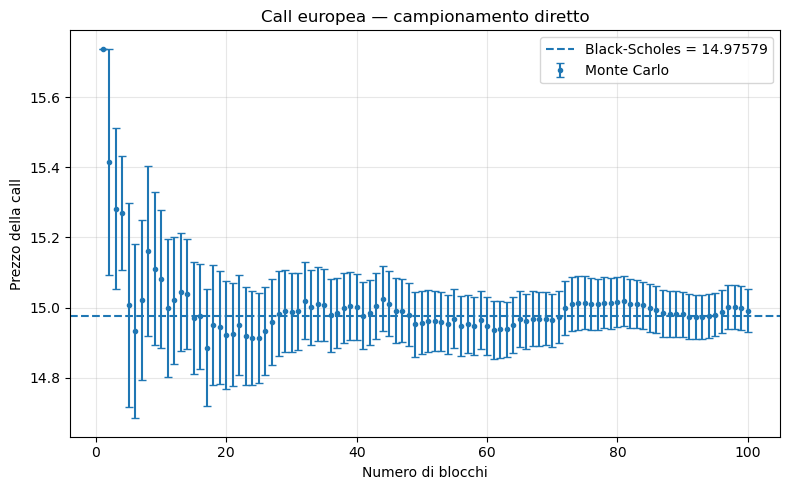

In [5]:
plot_progressive_estimate(
    data["call_direct"],
    call_exact,
    "Call europea — campionamento diretto",
    "Prezzo della call"
)

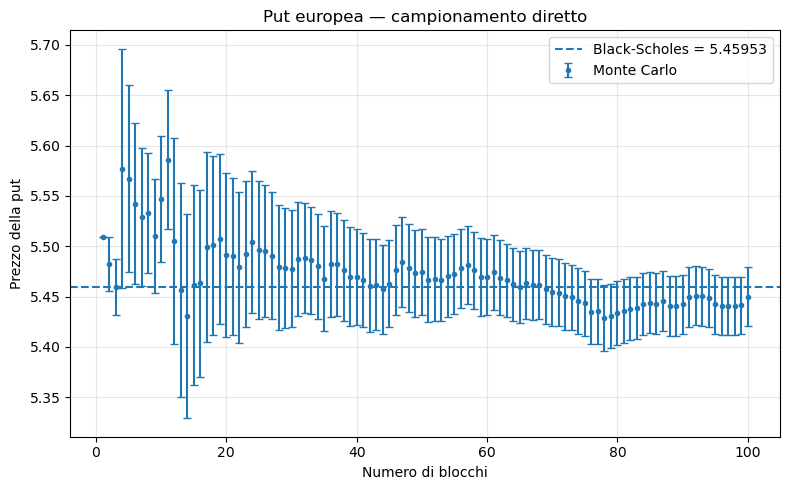

In [6]:
plot_progressive_estimate(
    data["put_direct"],
    put_exact,
    "Put europea — campionamento diretto",
    "Prezzo della put"
)

## Campionamento del cammino discretizzato

Nel secondo metodo simuliamo il cammino del moto browniano geometrico in $100$ passi temporali. Anche in questo caso il payoff finale dipende solo da $S(T)$, ma il metodo permette di verificare che la costruzione progressiva del processo riproduca correttamente il risultato analitico. Anche qui le incertezze sono calcolate con data blocking.

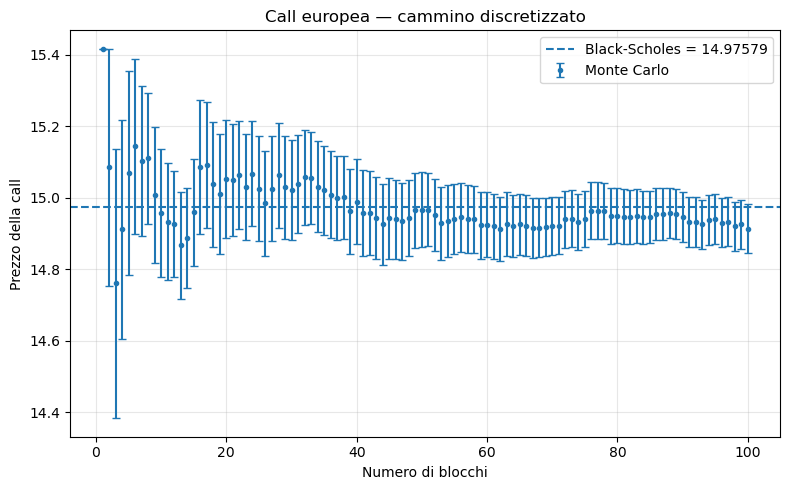

In [7]:
plot_progressive_estimate(
    data["call_discrete"],
    call_exact,
    "Call europea — cammino discretizzato",
    "Prezzo della call"
)

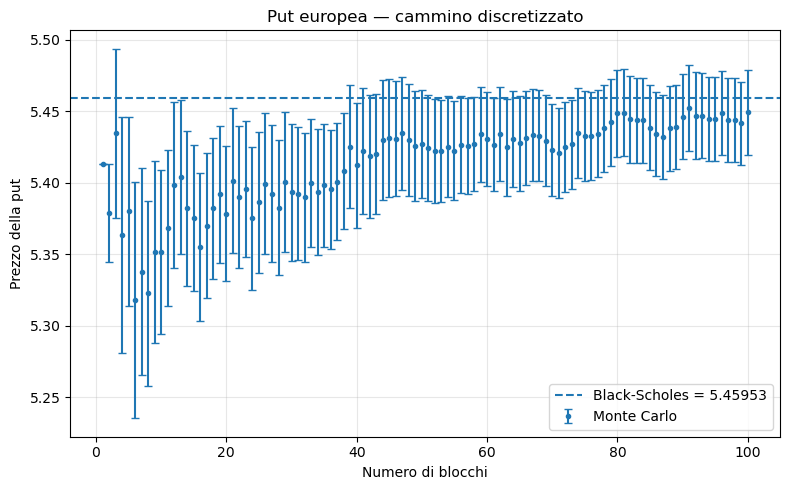

In [8]:
plot_progressive_estimate(
    data["put_discrete"],
    put_exact,
    "Put europea — cammino discretizzato",
    "Prezzo della put"
)

## Commento sui risultati

Dalla tabella si osserva che tutti gli scarti rispetto ai valori di Black-Scholes sono inferiori a una deviazione standard. Le quattro stime sono quindi compatibili con la soluzione analitica entro l'incertezza statistica.

In particolare, il metodo diretto e quello discretizzato forniscono risultati compatibili. Questo è atteso perché, nel caso del GBM con parametri costanti, la ricorrenza esponenziale usata nel metodo discretizzato campiona esattamente il processo sulla griglia temporale e non introduce un errore sistematico di discretizzazione.

Le differenze residue tra i risultati sono quindi attribuibili alle fluttuazioni statistiche del campionamento Monte Carlo.